In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
print("Số dòng rỗng ở cột TotalCharges:", df['TotalCharges'].isnull().sum())

Số dòng rỗng ở cột TotalCharges: 11


In [5]:
df.dropna(subset=['TotalCharges'], inplace=True)
df.drop('customerID', axis=1, inplace=True)
print(df.shape)

(7032, 20)


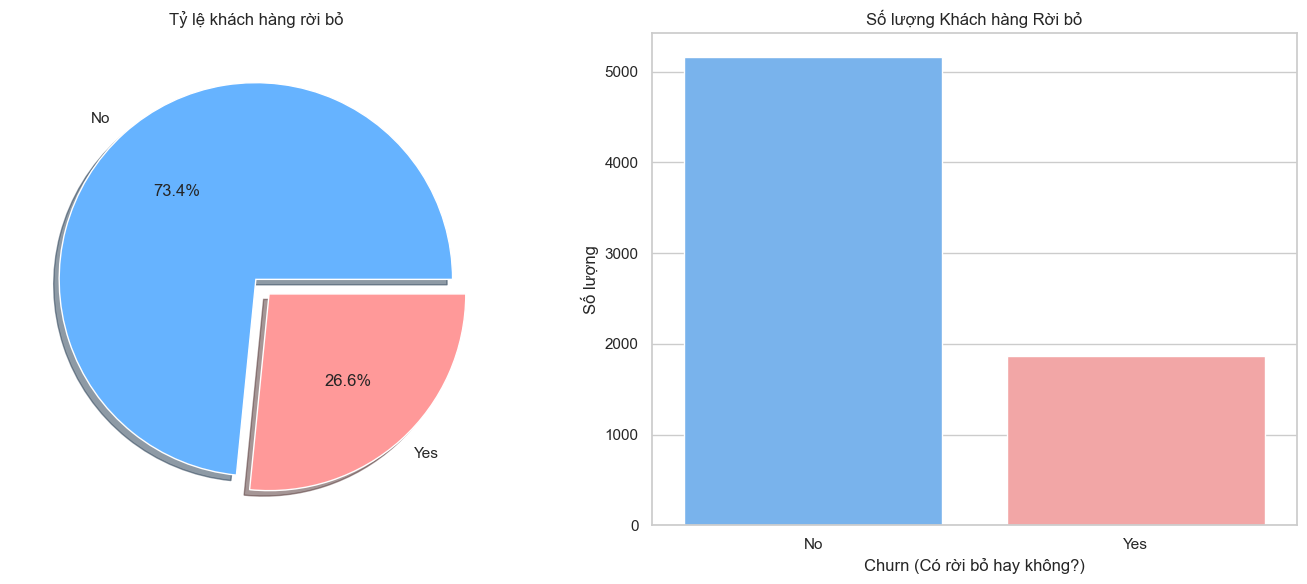

In [6]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(1,2, figsize = (14,6))

df['Churn'].value_counts().plot.pie(
    explode = [0, 0.1],
    autopct='%1.1f%%',
    ax = ax[0],
    shadow = True,
    colors = ['#66b3ff','#ff9999']
)

ax[0].set_title('Tỷ lệ khách hàng rời bỏ')
ax[0].set_ylabel('')

sns.countplot(x='Churn', data = df, ax = ax[1], palette=['#66b3ff','#ff9999'])
ax[1].set_title('Số lượng Khách hàng Rời bỏ')
ax[1].set_ylabel('Số lượng')
ax[1].set_xlabel('Churn (Có rời bỏ hay không?)')

plt.tight_layout()
plt.show()



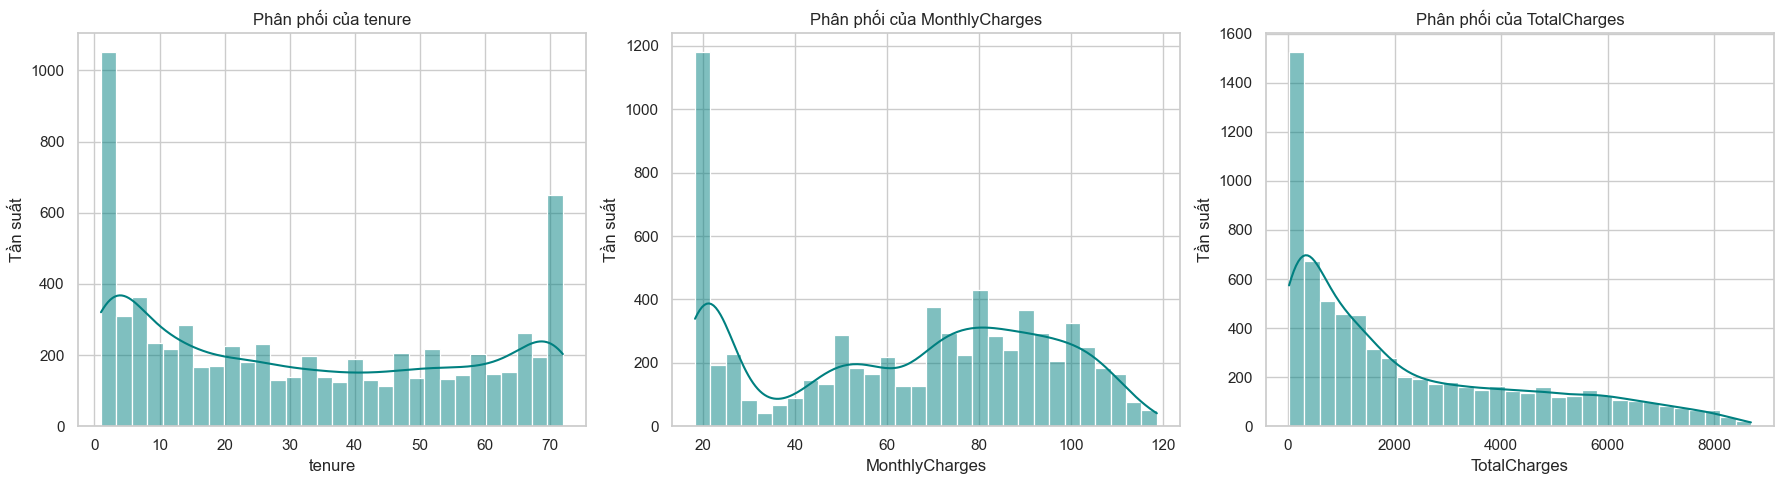

In [7]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize = (18,5))

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Phân phối của {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

## Xác định xem yếu tố nào đang ảnh hưởng đến quyết định rời đi của khách hàng

### Xét theo hai góc độ:
+) Phân tích các biến số

+) Phân tích các biến categories


# 1. Xác định xem tiền bạc và thời gian có ảnh hưởng ra sao

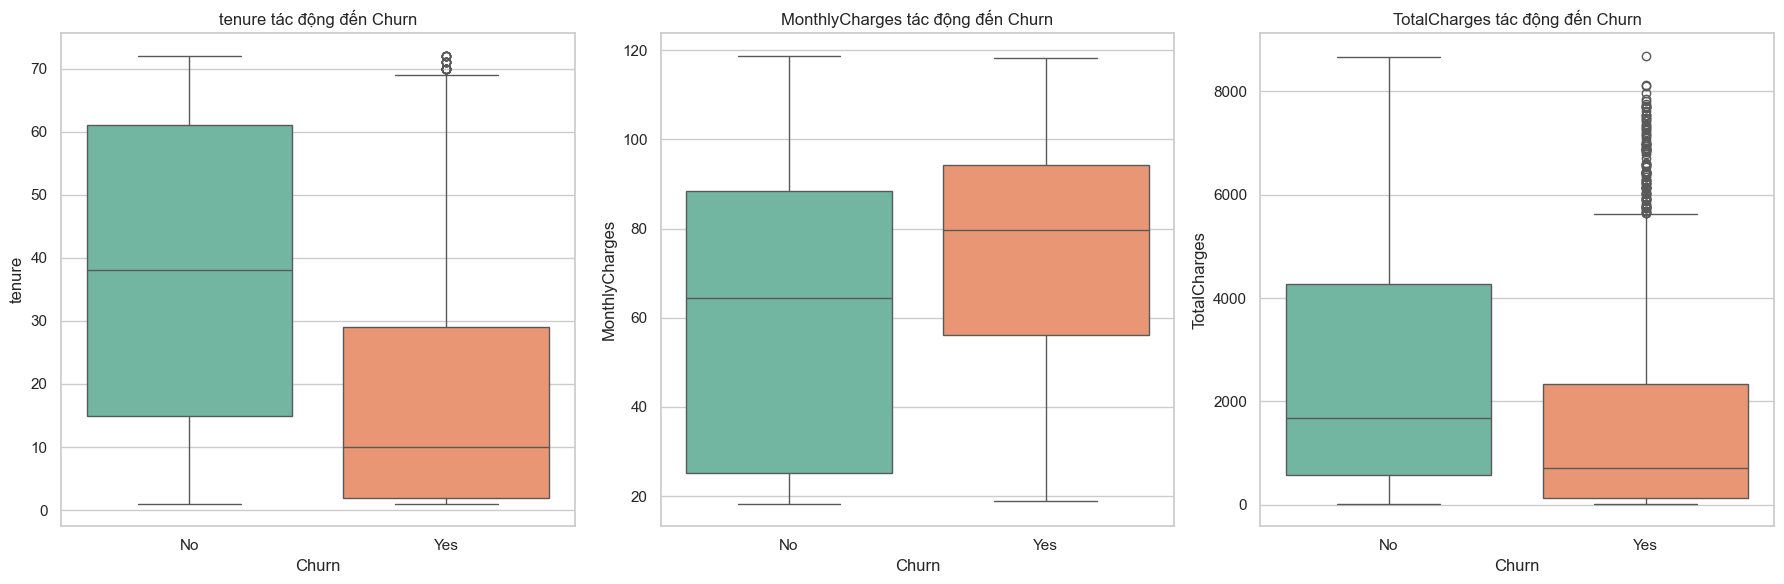

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

for i, col in enumerate(num_features):
    sns.boxplot(x='Churn', y = col, data = df, ax = axes[i], palette='Set2')
    axes[i].set_title(f'{col} tác động đến Churn')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('Churn')

plt.tight_layout()
plt.show()

# 2. Phân tích các biến categories

Sử dụng Chi_square để xác định các biến có ảnh hưởng đến quyết định rời đi


In [9]:
from scipy import stats

In [10]:
chi2_results = []

cat_colums = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in cat_colums:
    cat_colums.remove('Churn')

for col in cat_colums:
    contingency_table = pd.crosstab(df[col], df['Churn'])

    chi2_stat, p_val, dof, expected = stats.chi2_contingency(contingency_table)

    chi2_results.append({
        'Đặc trưng': col,
        'Điểm Chi_square': round(chi2_stat,2),
        'p_value': p_val
        })
    
chi2_df = pd.DataFrame(chi2_results)
chi2_df = chi2_df.sort_values(by="Điểm Chi_square", ascending = False).reset_index(drop=True)
display(chi2_df)

,Đặc trưng,Điểm Chi_square,p_value
0,Contract,1179.55,7.326182e-257
1,OnlineSecurity,846.68,1.400687e-184
2,TechSupport,824.93,7.407808e-180
3,InternetService,728.70,5.831199e-159
4,PaymentMethod,645.43,1.426310e-139
5,OnlineBackup,599.18,7.776099e-131
6,DeviceProtection,555.88,1.959389e-121
7,StreamingMovies,374.27,5.353560e-82
8,StreamingTV,372.46,1.324641e-81
9,PaperlessBilling,256.87,8.236203e-58


Dựa vào điểm Chi_square, ta có thể kết luận Contract, OnlineSecurity, TechSupport, InternetService và PaymentMethod ảnh hưởng đến Churn

Ta sẽ làm vẽ với 5 dữ liệu này trước


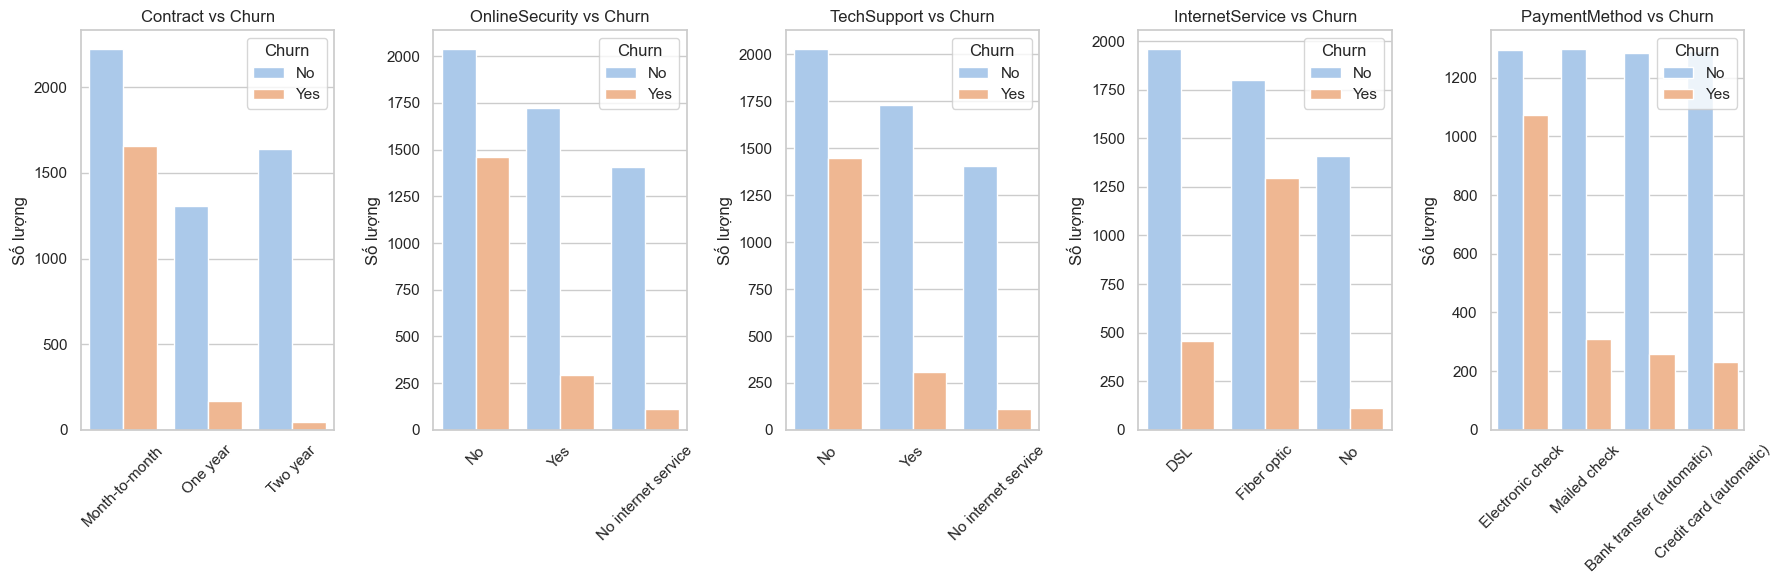

In [11]:
cat_features = ['Contract', 'OnlineSecurity', 'TechSupport', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_ylabel('Số lượng')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

Bỏ đi gender và Phonservice vì p_value>0.05 không thể bác bỏ giả thuyết nó không ảnh hưởng đến quyết định rời đi của khách hàng

In [12]:
df_cleaned = df.drop(columns= ['gender', 'PhoneService'])
df_cleaned.to_csv('telo_cleaned.csv', index = False)

In [13]:
df_cleaned.shape

(7032, 18)